# Oil Price Shocks and Texas Employment  

## Exploratory Data Analysis (EDA)

**Group:** Anthony Bauer, Jackson Daniel, Logan Averill  

This notebook performs the exploratory data analysis (EDA) for the project. The goal of this section is to better understand the cleaned dataset before moving into regression modeling.


## Purpose of EDA

The objective of this stage is to explore patterns, trends, and relationships in the data. This helps us:
- Identify potential data issues (outliers, missing values, inconsistencies)
- Understand distributions of key variables
- Explore relationships between oil prices, unemployment, and employment
- Form expectations about model coefficients before estimation


## Key Variables of Interest

- **WTI Oil Prices** – Measures fluctuations in oil markets  
- **Unemployment Rate (Texas)** – Captures broader labor market conditions  
- **Energy Employment (NAICS 211 & 213)** – Proxy for oil-related economic activity  
- **Employment Growth** – Outcome variable of interest  


## Workflow

1. Load the cleaned dataset from the ETL pipeline  
2. Inspect structure and summary statistics
3. Visualize distributions of key variables
4. Analyze trends over time (2010–2025)
5. Explore relationships between variables (correlations and plots)  


## Expectations (Prior to Modeling)

Before running any regression models, we have prior expectations based on economic intuition:

- Higher oil prices are expected to **increase energy-sector employment**  
- Rising oil prices should generally be associated with **lower unemployment** in Texas  
- The relationship may be **stronger during oil booms** and weaker or reversed during downturns  

If results later contradict these expectations, it likely indicates issues such as data errors, incorrect transformations, or omitted variables rather than a true causal effect.

All steps are written to be fully reproducible.

# 0) Setup and Initial Inspection

In [15]:
# Import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.3f}".format)

# Plot style
sns.set_theme(style="whitegrid")

# Load cleaned dataset from ETL notebook
df = pd.read_csv("../data_clean/final_dataset.csv")

# Preview the data
print("Dataset shape:")
print(df.shape)

print("\nFirst 5 rows:")
display(df.head())

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes)

print("\nMissing values by column:")
display(df.isna().sum().sort_values(ascending=False))

print("\nBasic summary statistics:")
display(df.describe())

Dataset shape:
(9295, 7)

First 5 rows:


,area_fips,year,qtr,emplvl,emplvl_growth,WTISPLC,TXUR
0,48001,2010,2,"1,668.000",-0.018,77.890,8.200
1,48001,2010,3,"1,699.000",0.019,76.167,8.133
2,48001,2010,4,"1,773.000",0.044,85.027,8.267
3,48001,2011,1,"1,758.000",-0.008,93.980,8.167
4,48001,2011,2,"1,892.000",0.076,102.553,8.200



Column names:
['area_fips', 'year', 'qtr', 'emplvl', 'emplvl_growth', 'WTISPLC', 'TXUR']

Data types:


area_fips          int64
year               int64
qtr                int64
emplvl           float64
emplvl_growth    float64
WTISPLC          float64
TXUR             float64
dtype: object


Missing values by column:


area_fips        0
year             0
qtr              0
emplvl           0
emplvl_growth    0
WTISPLC          0
TXUR             0
dtype: int64


Basic summary statistics:


,area_fips,year,qtr,emplvl,emplvl_growth,WTISPLC,TXUR
count,"9,295.000","9,295.000","9,295.000","9,295.000","9,295.000","9,295.000","9,295.000"
mean,"48,271.782","2,017.454",2.512,"5,098.220",-0.023,71.561,5.274
std,160.734,4.422,1.103,"24,408.634",0.283,20.680,1.680
min,"48,001.000","2,010.000",1.000,0.000,-1.000,27.807,3.433
25%,"48,141.000","2,014.000",2.000,197.500,-0.069,55.367,4.067
50%,"48,265.000","2,017.000",3.000,933.000,0.002,71.837,4.500
75%,"48,399.000","2,021.000",3.000,"2,682.333",0.062,92.270,6.500
max,"48,999.000","2,025.000",4.000,"381,564.667",1.000,108.723,11.533


# 1) Exploratory Graphs, Charts, and Plots

## Distribution of Key Variables

We begin the EDA by looking at the distributions of the main variables in the dataset. This helps identify skewness, outliers, and overall variability.

Understanding these distributions is important before modeling, as extreme values or non-normal shapes can influence regression results and interpretation.

Saving figures to: /Users/loganaverill/oil-employment-project/exports


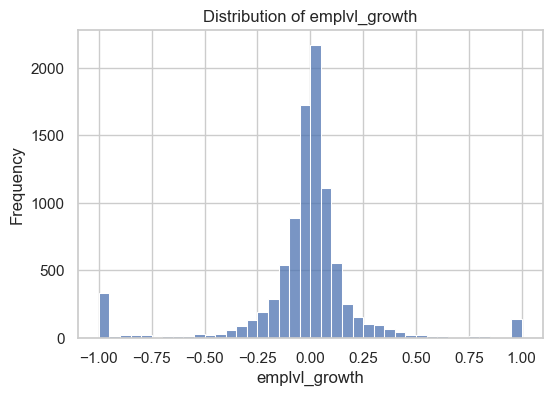

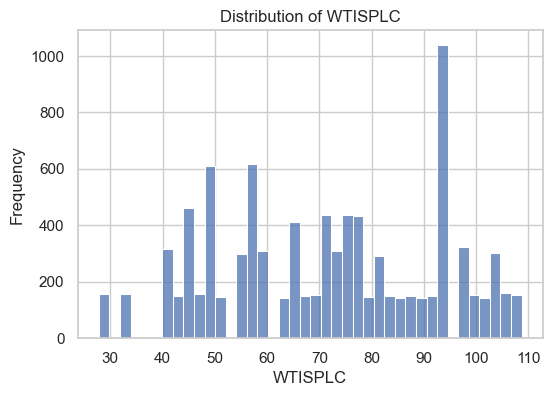

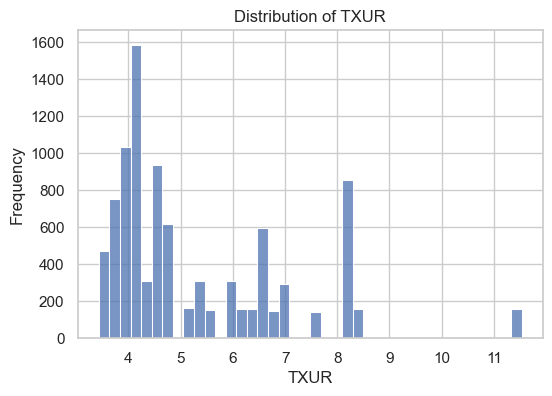

In [21]:
# Go up from notebooks folder to project root
base_path = os.path.abspath("..")

# Export folder at project level
export_path = os.path.join(base_path, "exports")

print("Saving figures to:", export_path)

# Variables to plot
vars_to_plot = ["emplvl_growth", "WTISPLC", "TXUR"]

for var in vars_to_plot:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[var], bins=40)
    plt.title(f"Distribution of {var}")
    plt.xlabel(var)
    plt.ylabel("Frequency")
    
    # Save figure to project-level exports folder
    plt.savefig(
        os.path.join(export_path, f"{var}_distribution.png"),
        dpi=300,
        bbox_inches="tight"
    )
    
    plt.show()
    plt.close()

## Interpretation of Key Variable Distributions

The distribution of **employment growth (emplvl_growth)** is centered close to zero, with most values between about -0.1 and 0.1. This means that, for most counties and quarters, employment doesn’t change very much. The values at -1 and 1 come from capped extreme cases, which likely happen when employment was very small to begin with. Overall, the distribution is slightly skewed, but large changes in employment are not very common.

The distribution of **WTI oil prices (WTISPLC)** covers a wide range, from around $30 to over $100 per barrel. This shows that oil prices vary a lot over time, with clear periods of low prices and high prices. The distribution has multiple peaks, which makes sense because oil prices tend to move in cycles rather than staying stable.

The distribution of the **Texas unemployment rate (TXUR)** is more concentrated, with most values between about 3.5% and 6%. There are some higher values above 8%, which likely reflect economic downturns like COVID-19. Compared to oil prices, unemployment changes less dramatically over time.

Overall, oil prices show the most variation, employment growth is mostly stable with some extreme cases, and unemployment stays within a relatively narrow range. These differences will be important to keep in mind when we analyze relationships between these variables later.

## Time Trends in Oil Prices and Employment Growth

To better understand the relationship between oil prices and employment, we examine how these variables evolve over time. Since our research question focuses on whether changes in oil prices predict employment growth, visualizing trends over time is critical.

We aggregate the data to the quarterly level to observe overall patterns across Texas. This allows us to compare movements in oil prices with changes in employment growth and identify periods of expansion and contraction.

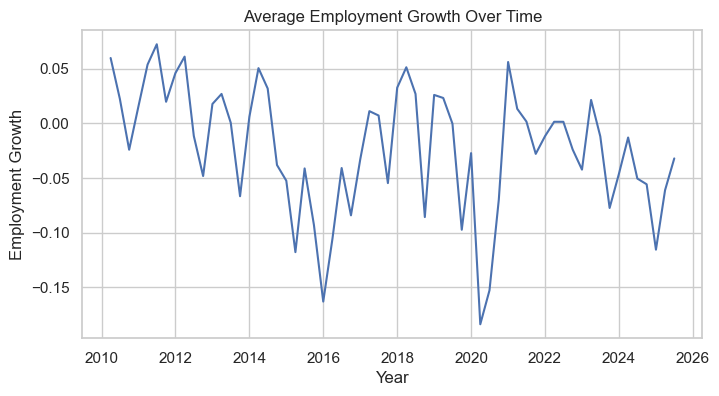

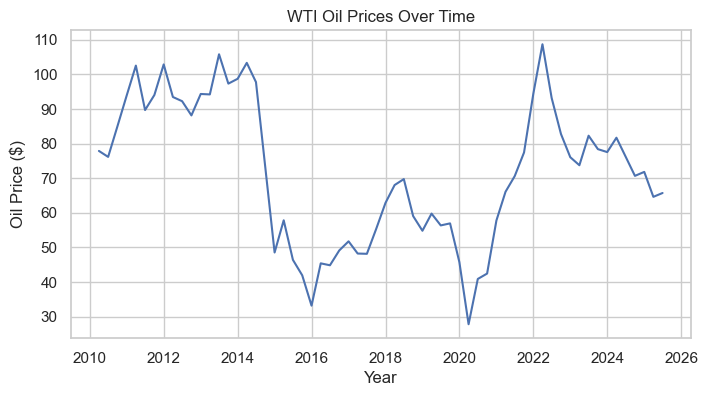

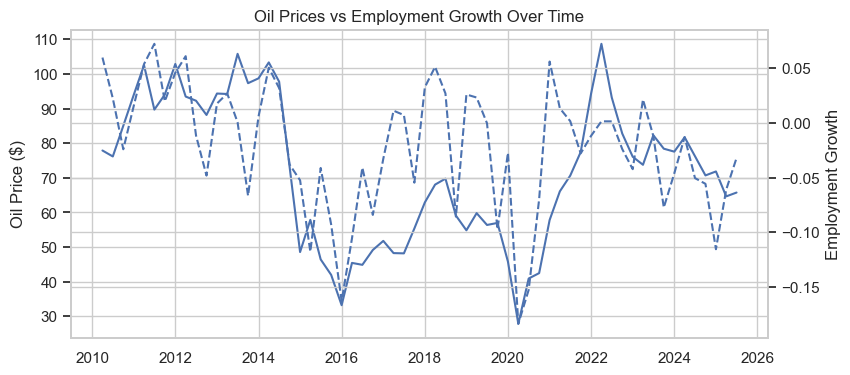

In [23]:
# Create a proper time variable
df["date"] = pd.PeriodIndex(year=df["year"], quarter=df["qtr"]).to_timestamp()

# Aggregate to quarterly averages across counties
df_time = df.groupby("date", as_index=False).agg({
    "emplvl_growth": "mean",
    "WTISPLC": "mean",
    "TXUR": "mean"
})

# Sort by time
df_time = df_time.sort_values("date")

# Set export path
base_path = os.path.abspath("..")
export_path = os.path.join(base_path, "exports")
os.makedirs(export_path, exist_ok=True)

# Plot 1: Employment Growth
plt.figure(figsize=(8,4))
plt.plot(df_time["date"], df_time["emplvl_growth"])
plt.title("Average Employment Growth Over Time")
plt.xlabel("Year")
plt.ylabel("Employment Growth")

plt.savefig(os.path.join(export_path, "employment_growth_time.png"),
            dpi=300, bbox_inches="tight")

plt.show()
plt.close()

# Plot 2: Oil Prices
plt.figure(figsize=(8,4))
plt.plot(df_time["date"], df_time["WTISPLC"])
plt.title("WTI Oil Prices Over Time")
plt.xlabel("Year")
plt.ylabel("Oil Price ($)")

plt.savefig(os.path.join(export_path, "oil_price_time.png"),
            dpi=300, bbox_inches="tight")

plt.show()
plt.close()

# Plot 3: Combined (key plot)
fig, ax1 = plt.subplots(figsize=(9,4))

ax1.plot(df_time["date"], df_time["WTISPLC"], label="Oil Price")
ax1.set_ylabel("Oil Price ($)")

ax2 = ax1.twinx()
ax2.plot(df_time["date"], df_time["emplvl_growth"], linestyle="--", label="Employment Growth")
ax2.set_ylabel("Employment Growth")

plt.title("Oil Prices vs Employment Growth Over Time")

plt.savefig(os.path.join(export_path, "oil_vs_growth_time.png"),
            dpi=300, bbox_inches="tight")

plt.show()
plt.close()

## Interpretation of Oil Prices and Employment Growth Over Time

The time series plot shows how oil prices and employment growth change from 2010 to 2025. Oil prices clearly move in cycles, with big drops around 2014–2016 and again in 2020, followed by a strong increase leading into 2022. This reflects how volatile oil markets can be.

Employment growth is more stable overall but still shows some ups and downs. Most of the time it stays close to zero, meaning employment doesn’t change drastically from quarter to quarter. However, there are periods where growth becomes more negative, especially during major drops in oil prices.

For example, when oil prices fall sharply around 2015 and 2020, employment growth also tends to decline. This suggests that lower oil prices may hurt employment in energy-related industries. On the other hand, when oil prices rise, employment growth seems to improve.

That being said, the relationship is not perfect. There are times when employment growth does not move exactly with oil prices, which means other factors besides oil are also affecting employment.

Overall, the graph suggests a positive relationship between oil prices and employment growth. Higher oil prices are generally associated with better employment outcomes, but more analysis is needed to confirm this.

## Relationship Between Oil Prices and Employment Growth

To further explore the relationship between oil prices and employment growth, we use scatter plots and correlation analysis. 

Scatter plots allow us to visualize whether there is a clear pattern between the two variables, while correlation provides a summary measure of the strength and direction of their relationship. This helps us understand whether higher oil prices are generally associated with higher employment growth before running regression models.

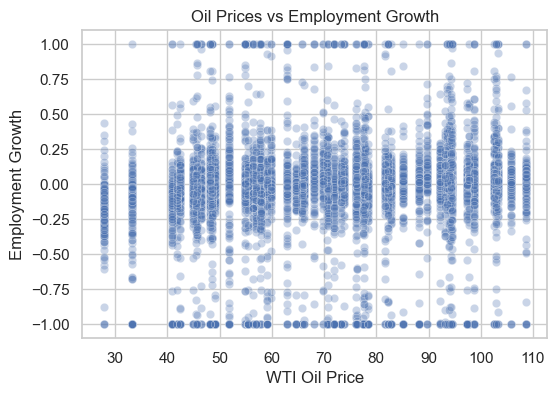

Correlation Matrix:
               WTISPLC  emplvl_growth  TXUR
WTISPLC          1.000          0.118 0.155
emplvl_growth    0.118          1.000 0.010
TXUR             0.155          0.010 1.000


In [24]:
# Set export path
base_path = os.path.abspath("..")
export_path = os.path.join(base_path, "exports")
os.makedirs(export_path, exist_ok=True)

# Scatter: Oil Price vs Employment Growth
plt.figure(figsize=(6,4))
sns.scatterplot(x=df["WTISPLC"], y=df["emplvl_growth"], alpha=0.3)

plt.title("Oil Prices vs Employment Growth")
plt.xlabel("WTI Oil Price")
plt.ylabel("Employment Growth")

plt.savefig(os.path.join(export_path, "scatter_oil_vs_growth.png"),
            dpi=300, bbox_inches="tight")

plt.show()
plt.close()

# Correlation
corr = df[["WTISPLC", "emplvl_growth", "TXUR"]].corr()
print("Correlation Matrix:")
print(corr)

## Interpretation of Scatter Plot and Correlation

The scatter plot shows the relationship between oil prices and employment growth, but the points are very spread out. This means there is not a strong or clear relationship between the two variables. While there may be a slight upward trend, it is not very noticeable from the plot alone.

The correlation between oil prices and employment growth is about **0.118**, which is positive but quite small. This suggests that higher oil prices are associated with slightly higher employment growth, but the relationship is weak.

The correlation between oil prices and unemployment is **0.155**, which is also small. The relationship between unemployment and employment growth is close to zero (**0.010**), indicating almost no linear relationship between those two variables in this dataset.

Overall, these results suggest that oil prices may have some influence on employment growth, but the effect is not strong. Other factors are likely playing a large role in determining employment changes. This means that while oil prices are important, they alone do not explain most of the variation in employment growth, which is something we will explore further in the regression analysis.

## EDA Conclusion

In this section, we explored the key variables in the dataset and examined their distributions, time trends, and relationships. The results show that employment growth is generally stable with small changes over time, while oil prices vary much more and follow clear cycles. Unemployment rates are more tightly distributed, with occasional spikes during economic downturns.

The time series analysis suggests that large drops in oil prices tend to line up with weaker or negative employment growth, which supports the idea that oil markets may influence employment in energy-related industries. However, the scatter plot and correlation analysis show that this relationship is relatively weak, indicating that oil prices alone do not explain most of the variation in employment growth.

### Limitations

There are several limitations to keep in mind. First, employment growth was calculated as a percentage change, which can be sensitive to small starting values, even after capping extreme observations. Second, the data is aggregated at the county level, which may hide differences within counties. Third, oil prices and unemployment are measured at broader levels and may not fully capture local economic conditions. Finally, the analysis is descriptive and does not establish causation.

Overall, the EDA suggests that there may be a relationship between oil prices and employment growth, but it is not strong on its own. This motivates the use of regression analysis in the next section to better understand and quantify this relationship.